In [ ]:
import pandas as pd

df = pd.read_csv("earthquake_1995-2023.csv")

print("Rows and columns :", df.shape)
df.head()           # show the first 5 rows

Rows and columns : (1000, 19)


,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16-08-2023 12:47,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19-07-2023 00:22,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17-07-2023 03:05,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16-07-2023 06:48,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16-07-2023 06:48,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN


In [ ]:
#.info

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      1000 non-null   str    
 1   magnitude  1000 non-null   float64
 2   date_time  1000 non-null   str    
 3   cdi        1000 non-null   int64  
 4   mmi        1000 non-null   int64  
 5   alert      449 non-null    str    
 6   tsunami    1000 non-null   int64  
 7   sig        1000 non-null   int64  
 8   net        1000 non-null   str    
 9   nst        1000 non-null   int64  
 10  dmin       1000 non-null   float64
 11  gap        1000 non-null   float64
 12  magType    1000 non-null   str    
 13  depth      1000 non-null   float64
 14  latitude   1000 non-null   float64
 15  longitude  1000 non-null   float64
 16  location   994 non-null    str    
 17  continent  284 non-null    str    
 18  country    651 non-null    str    
dtypes: float64(6), int64(5), str(8)
memory usage: 148.6 KB


In [ ]:
print("Exact duplicate rows:", df.duplicated().sum())

Exact duplicate rows: 0


In [ ]:
dupe_mask = df.duplicated(subset=["title", "date_time"], keep=False)

print("Rows involved in a title + date_time duplicate:", dupe_mask.sum())

print(df[dupe_mask][["title", "date_time"]])

Rows involved in a title + date_time duplicate: 4
                                   title         date_time
67  M 6.5 - 71 km SE of Nikolski, Alaska  11-01-2022 12:39
68  M 6.5 - 71 km SE of Nikolski, Alaska  11-01-2022 12:39
70  M 6.7 - 91 km SE of Nikolski, Alaska  11-01-2022 11:35
71  M 6.7 - 91 km SE of Nikolski, Alaska  11-01-2022 11:35


In [ ]:
before = len(df)

df = df.drop_duplicates(subset=["title", "date_time"])

after = len(df)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicates removed:", before - after)

Rows before removing duplicates: 1000
Rows after removing duplicates: 998
Duplicates removed: 2


In [ ]:
missing_count = df.isnull().sum()

missing_percentage = (missing_count / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

print(missing_report)

           Missing Count  Missing Percentage
title                  0            0.000000
magnitude              0            0.000000
date_time              0            0.000000
cdi                    0            0.000000
mmi                    0            0.000000
alert                549           55.010020
tsunami                0            0.000000
sig                    0            0.000000
net                    0            0.000000
nst                    0            0.000000
dmin                   0            0.000000
gap                    0            0.000000
magType                0            0.000000
depth                  0            0.000000
latitude               0            0.000000
longitude              0            0.000000
location               6            0.601202
continent            714           71.543086
country              347           34.769539


In [ ]:
numeric_columns = ["cdi", "gap", "nst", "dmin"]

for col in numeric_columns:
    print("\n", col)
    print("Number of zeros:", (df[col] == 0).sum())


 cdi
Number of zeros: 395

 gap
Number of zeros: 252

 nst
Number of zeros: 519

 dmin
Number of zeros: 586


In [ ]:
import numpy as np

for col in numeric_columns:
    df[col] = df[col].replace(0, np.nan)

print("Zeros converted to NaN.")

Zeros converted to NaN.


In [ ]:
print(df[numeric_columns].isnull().sum())

cdi     395
gap     252
nst     519
dmin    586
dtype: int64


Mean medainn mode

Matplotlib is building the font cache; this may take a moment.



Column: gap
Skewness: 4.885701324053703


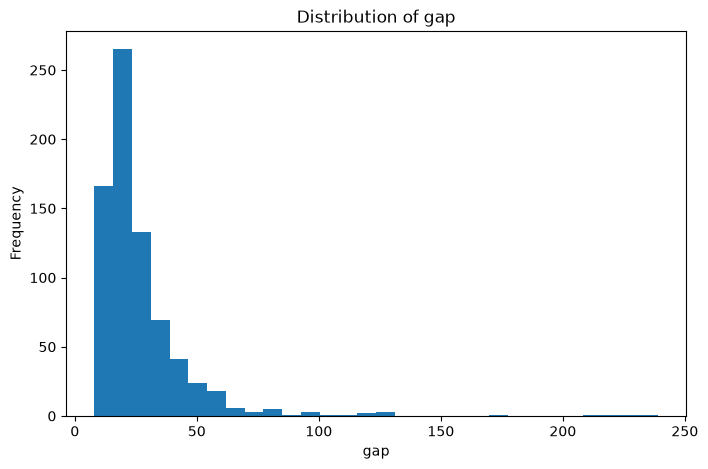


Column: dmin
Skewness: 1.9997583308140012


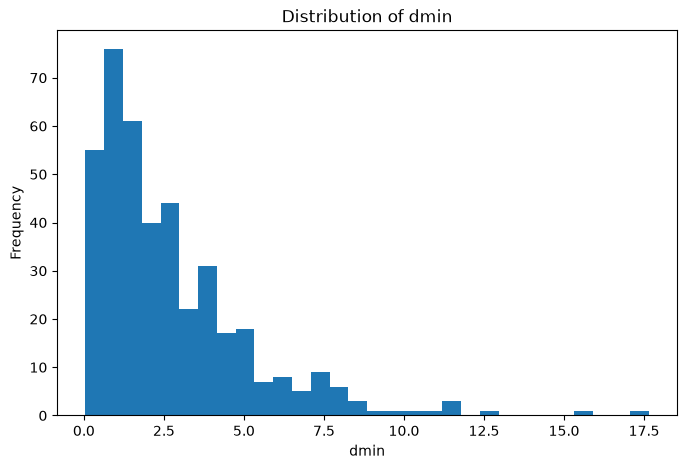

In [ ]:
import matplotlib.pyplot as plt

columns_to_check = ["gap", "dmin"]

for col in columns_to_check:

    print("\nColumn:", col)
    print("Skewness:", df[col].skew())

    plt.figure(figsize=(8, 5))
    plt.hist(df[col].dropna(), bins=30)
    plt.title("Distribution of " + col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [ ]:
# Example: median for skewed data
df["gap"] = df["gap"].fillna(df["gap"].median())

# Example: mean for approximately symmetric data
df["dmin"] = df["dmin"].fillna(df["dmin"].mean())

In [ ]:
print("Missing alert values:", df["alert"].isnull().sum())

df["alert"] = df["alert"].fillna(df["alert"].mode()[0])

Missing alert values: 549


In [ ]:
df["location"] = df["location"].fillna("Unknown")

In [ ]:
print(df.isnull().sum())

title          0
magnitude      0
date_time      0
cdi          395
mmi            0
alert          0
tsunami        0
sig            0
net            0
nst          519
dmin           0
gap            0
magType        0
depth          0
latitude       0
longitude      0
location       0
continent    714
country      347
dtype: int64


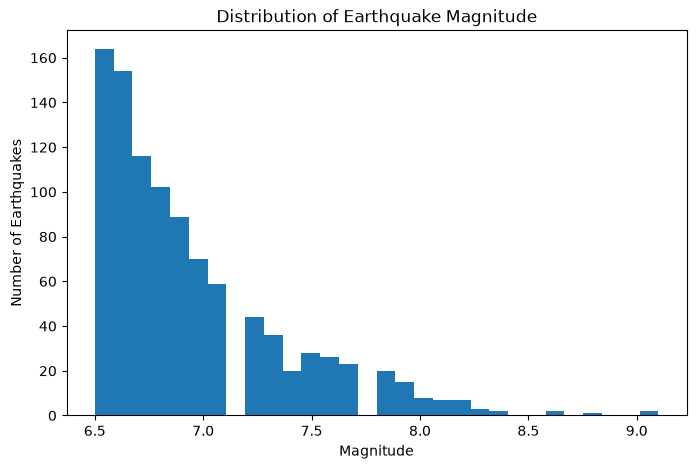

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df["magnitude"].dropna(), bins=30)

plt.title("Distribution of Earthquake Magnitude")
plt.xlabel("Magnitude")
plt.ylabel("Number of Earthquakes")

plt.show()

In [ ]:
print("Remaining missing values:")
print(df.isnull().sum())

Remaining missing values:
title          0
magnitude      0
date_time      0
cdi          395
mmi            0
alert          0
tsunami        0
sig            0
net            0
nst          519
dmin           0
gap            0
magType        0
depth          0
latitude       0
longitude      0
location       0
continent    714
country      347
dtype: int64


In [ ]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 1975




---




# Import Dataset

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("earthquake_1995-2023.csv")

print(df.shape)
df.head()

(1000, 19)


,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16-08-2023 12:47,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19-07-2023 00:22,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17-07-2023 03:05,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16-07-2023 06:48,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16-07-2023 06:48,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN


## 📊 Bar Graph
Top 10 Countries with Earthquakes

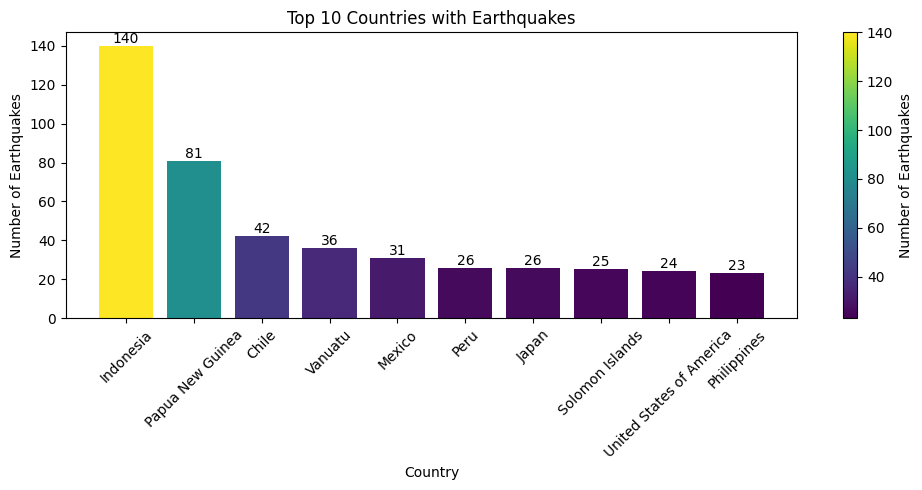

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

country_count = df['country'].value_counts().head(10)

# Create figure and axes
fig, ax = plt.subplots(figsize=(10, 5))

# Normalize earthquake counts
norm = colors.Normalize(
    vmin=country_count.min(),
    vmax=country_count.max()
)

# Create colors based on number of earthquakes
bar_colors = cm.viridis(norm(country_count.values))

# Create bars
bars = ax.bar(
    country_count.index,
    country_count.values,
    color=bar_colors
)

# Titles and labels
ax.set_title('Top 10 Countries with Earthquakes')
ax.set_xlabel('Country')
ax.set_ylabel('Number of Earthquakes')
ax.tick_params(axis='x', rotation=45)

# Display values on top of bars
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha='center',
        va='bottom'
    )

# Add color map
sm = cm.ScalarMappable(norm=norm, cmap='viridis')
sm.set_array(country_count.values)

fig.colorbar(
    sm,
    ax=ax,
    label='Number of Earthquakes'
)

plt.tight_layout()
plt.show()

**Conclusion:**

The bar graph shows that some countries have significantly more recorded earthquakes than others. It helps identify the countries with the highest number of earthquakes in the dataset.

## 📊 Grouped Bar Graph
Earthquake Alerts by Continent

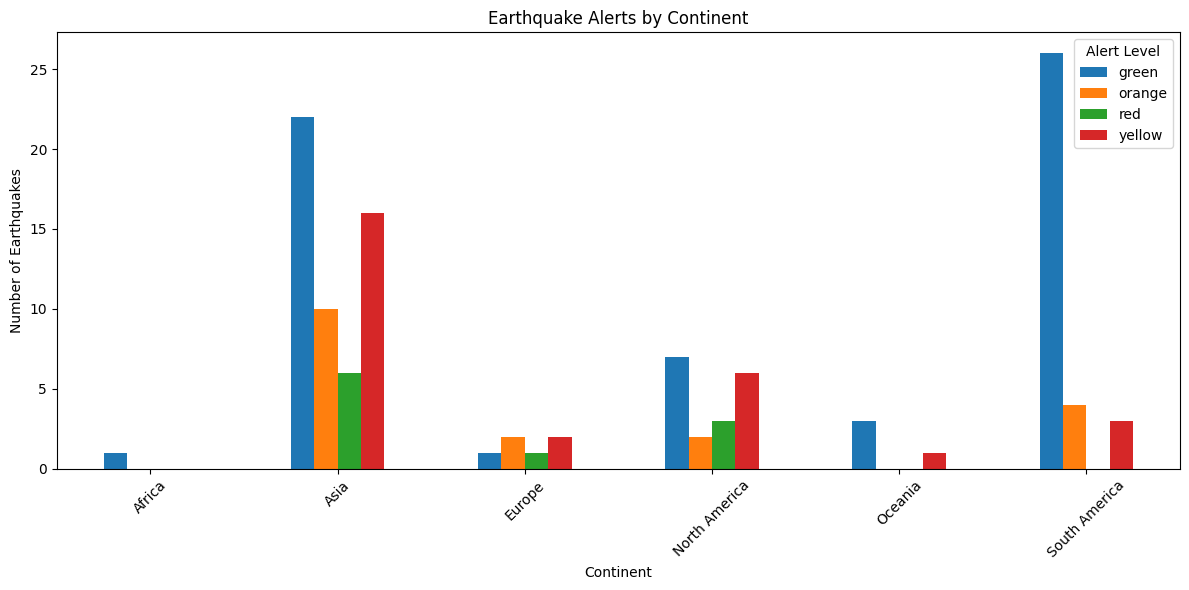

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.crosstab(df['continent'], df['alert'])

data.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Earthquake Alerts by Continent')
plt.xlabel('Continent')
plt.ylabel('Number of Earthquakes')
plt.xticks(rotation=45)
plt.legend(title='Alert Level')

plt.tight_layout()
plt.show()

**Conclusion:**

The grouped bar graph compares different earthquake alert levels across continents. It shows that the distribution of alert levels varies between continents, allowing us to compare the number of earthquakes under each alert category.

## 📊 Stacked Bar Graph
Earthquake Alerts by Continent

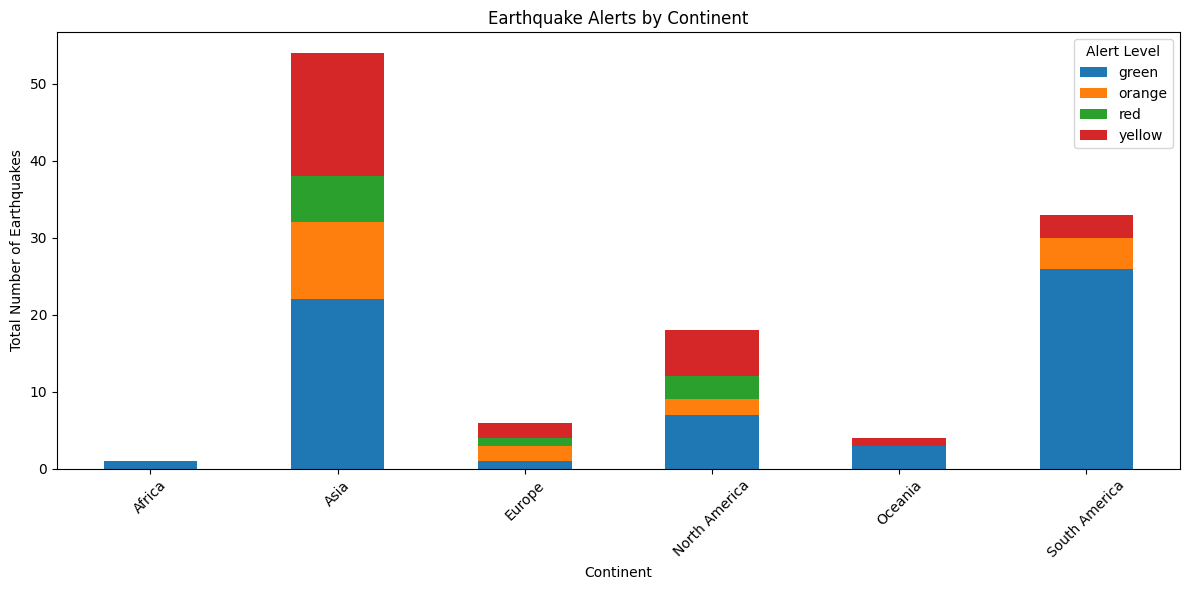

In [9]:
data = pd.crosstab(df['continent'], df['alert'])

data.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Earthquake Alerts by Continent')
plt.xlabel('Continent')
plt.ylabel('Total Number of Earthquakes')
plt.xticks(rotation=45)
plt.legend(title='Alert Level')

plt.tight_layout()
plt.show()

**Conclusion:**

The stacked bar graph shows the total earthquake records for each continent while also showing how different alert levels contribute to that total. It helps us understand the overall composition of earthquake alerts within each continent.

## 📈 Histogram
Distribution of Earthquake Magnitudes

Number of Bins: 10
Bin Size / Width: 0.26

Bin Range		Frequency
--------------------------------
6.50 - 6.76		436
6.76 - 7.02		261
7.02 - 7.28		103
7.28 - 7.54		84
7.54 - 7.80		49
7.80 - 8.06		43
8.06 - 8.32		17
8.32 - 8.58		2
8.58 - 8.84		3
8.84 - 9.10		2


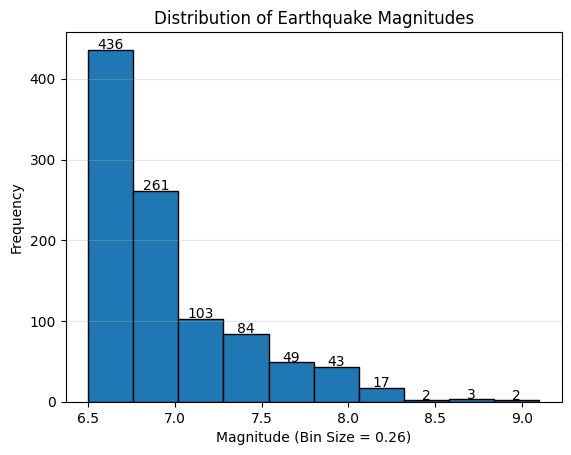

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Remove missing values
magnitude = df['magnitude'].dropna()

# Number of bins
num_bins = 10

# Minimum and maximum magnitude
min_mag = magnitude.min()
max_mag = magnitude.max()

# Bin size
bin_width = (max_mag - min_mag) / num_bins

# Create histogram
frequency, bins, patches = plt.hist(
    magnitude,
    bins=num_bins,
    edgecolor='black'
)

print("Number of Bins:", num_bins)
print("Bin Size / Width:", round(bin_width, 2))

print("\nBin Range\t\tFrequency")
print("--------------------------------")

for i in range(len(frequency)):
    print(
        f"{bins[i]:.2f} - {bins[i+1]:.2f}\t\t{int(frequency[i])}"
    )

# Show frequency on bars
for i in range(len(frequency)):
    plt.text(
        (bins[i] + bins[i+1]) / 2,
        frequency[i] + 1,
        str(int(frequency[i])),
        ha='center'
    )

plt.title('Distribution of Earthquake Magnitudes')
plt.xlabel(f'Magnitude (Bin Size = {bin_width:.2f})')
plt.ylabel('Frequency')

plt.grid(axis='y', alpha=0.3)

plt.show()

**Conclusion:**

The histogram shows the distribution of earthquake magnitudes. Most earthquakes in the dataset are concentrated within certain magnitude ranges, while high-magnitude earthquakes occur less frequently.

## 🥧 Pie Chart
Earthquakes by Continent

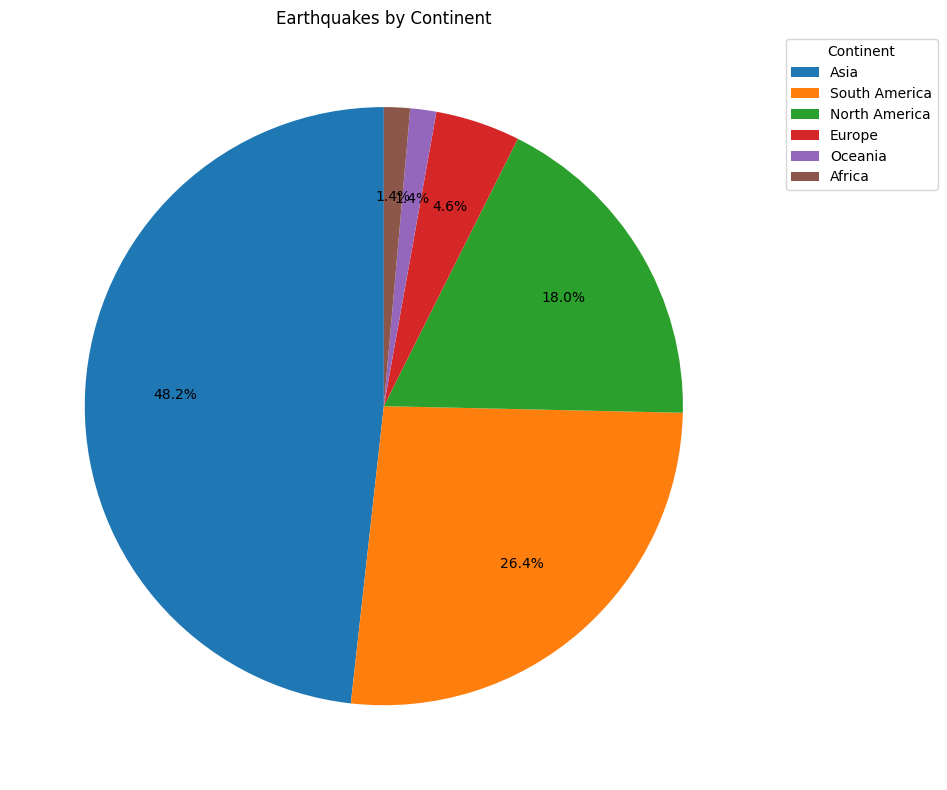

In [11]:
import matplotlib.pyplot as plt

# Count earthquakes by continent
continent_count = df['continent'].value_counts()

# Create pie chart
fig, ax = plt.subplots(figsize=(9, 8))

wedges, texts, autotexts = ax.pie(
    continent_count,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.7
)

# Legend with the matching colors and names
ax.legend(
    wedges,
    continent_count.index,
    title="Continent",
    loc="upper right",
    bbox_to_anchor=(1.25, 1)
)

ax.set_title("Earthquakes by Continent")

plt.tight_layout()
plt.show()

**Conclusion:**

The pie chart shows the percentage distribution of earthquakes across continents. Asia has the largest share in the dataset, followed by South America and North America, while the remaining continents contribute smaller shares.

## 🔵 Scatter Plot
Earthquake Magnitude vs Depth

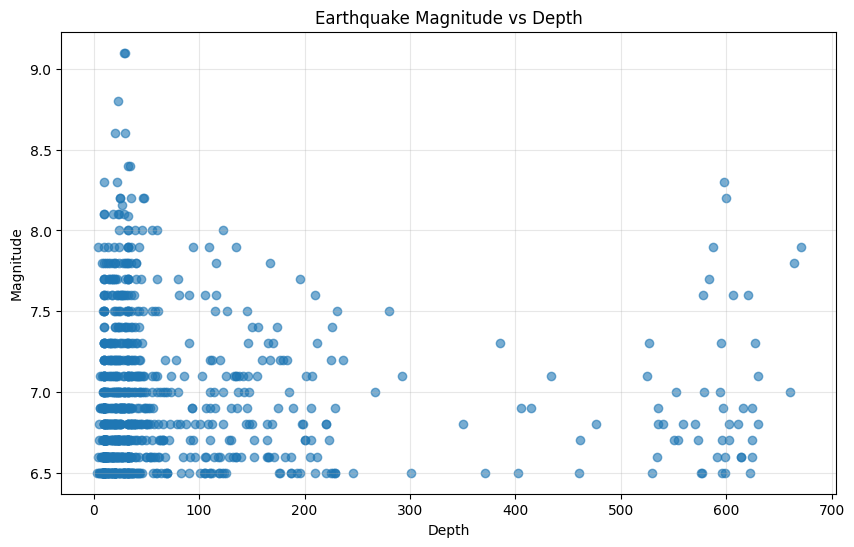

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df['depth'],
    df['magnitude'],
    alpha=0.6
)

plt.title('Earthquake Magnitude vs Depth')
plt.xlabel('Depth')
plt.ylabel('Magnitude')

plt.grid(alpha=0.3)

plt.show()

**Conclusion:**

The scatter plot shows the relationship between earthquake depth and magnitude. The points are spread across different depths and magnitudes, indicating that earthquake magnitude does not have a simple direct relationship with depth in this dataset.

## 📈 Line Plot
Number of Earthquakes per Year

/tmp/ipykernel_552/2203327071.py:5: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date_time'] = pd.to_datetime(df['date_time'])


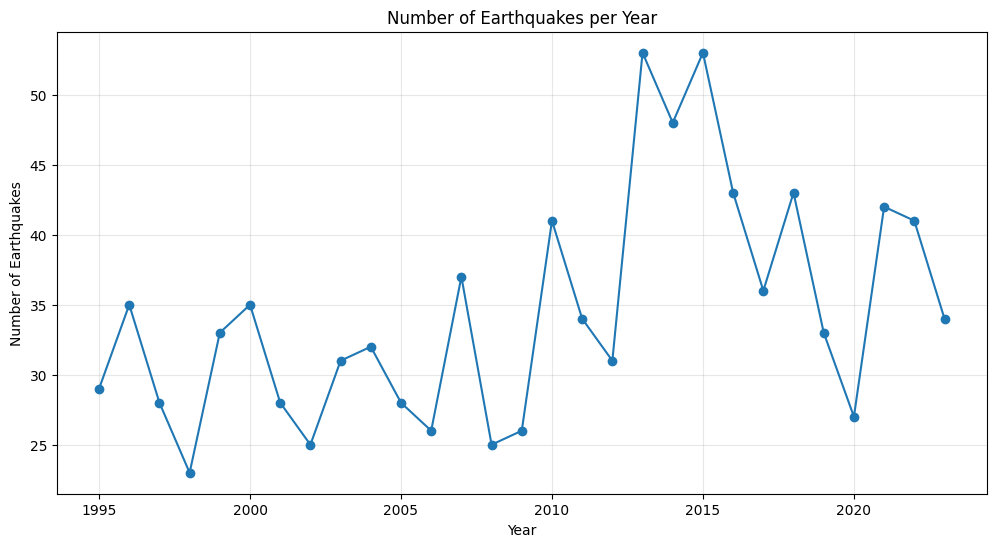

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert date_time to datetime
df['date_time'] = pd.to_datetime(df['date_time'])

# Count earthquakes by year
yearly_count = df['date_time'].dt.year.value_counts().sort_index()

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_count.index,
    yearly_count.values,
    marker='o'
)

plt.title('Number of Earthquakes per Year')
plt.xlabel('Year')
plt.ylabel('Number of Earthquakes')

plt.grid(alpha=0.3)

plt.show()

**Conclusion:**

The line plot shows how the number of recorded earthquakes changes over the years from 1995 to 2023. The number varies from year to year, showing fluctuations in the recorded earthquake activity.